h value: 0.01, y average: 1.91
h value: 0.05, y average: 1.02
h value: 0.15, y average: 0.32
h value: 0.2, y average: 0.20
h value: 0.25, y average: 0.14
h value: 0.5, y average: 0.02
h value: 0.75, y average: 0.05
h value: 1.0, y average: 2.01


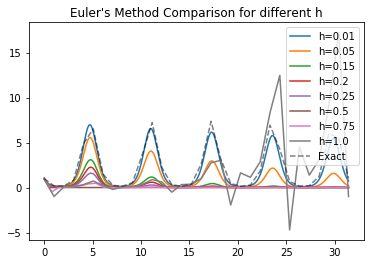

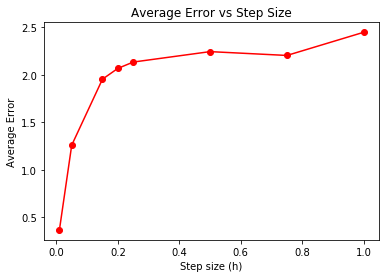

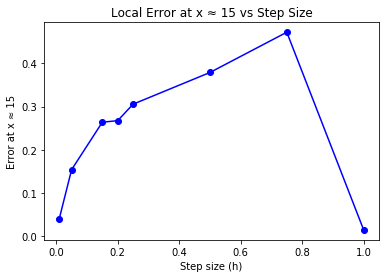

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
x_start, x_end = 0, 10 * np.pi
h_values = [.01, .05, .15, .2, .25, .5, .75, 1.0]

# Initial condition
y_values[0] = 1 # y(0) = 1

# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

#Find the exact solution
def exact_sol(x):
    return np.exp(-2 * np.sin(x))

#storage for plotting
avg_errors = []
local_errors_at_15 = []

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = 1
    
    # Implement Euler's method
    for i in range(num_steps):
        y[i + 1] = y[i] + h * f(x[i], y[i])
        
    y_avg = np.average(y)
    print(f'h value: {h}, y average: {y_avg:.2f}')
    # Calculate Errors
    y_true = exact_sol(x)
    error = np.abs(y_true - y)
    
    avg_errors.append(np.mean(error))
    
    # Find index closest to x = 15
    idx_15 = np.argmin(np.abs(x - 15))
    local_errors_at_15.append(error[idx_15])
    
    # Plot 1: Euler comparisons
    plt.plot(x, y, label=f'h={h}')

# Finalize Plot 1
plt.plot(x, exact_sol(x), 'k--', label='Exact', alpha=0.5)
plt.title("Euler's Method Comparison for different h")
plt.legend()
plt.show()

# 3. Plot 2: Average Error vs h
plt.figure()
plt.plot(h_values, avg_errors, 'o-r')
plt.xlabel('Step size (h)')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.show()

# 4. Plot 3: Local Error at x ≈ 15
plt.figure()
plt.plot(h_values, local_errors_at_15, 'o-b')
plt.xlabel('Step size (h)')
plt.ylabel('Error at x ≈ 15')
plt.title('Local Error at x ≈ 15 vs Step Size')
plt.show()

As h increases, the accuracy of the approximation decreases because a linear approximation is being used to estimate a curved solution, meaning the larger steps fail to capture the curvature. Local error is proportial to h^2, and the global error acumulates over time.

The difference between this and f(x, y) = -2y is that the lambda is now variable due to the introduction of an x term, so the stability condition also varies. For example, when cos(x) = 0, lamba is zero, so the equation is "infintely stable", when cos(x) = 1 lambda is -2 and the stability condition is tightest h<=1, and when cos(x) = -1 lambda is 2, and the equation is purely unstable. The overall lamda is -2cos(x). The maximum value of lamba is the absolute value of -2cos(x), so |-2 * 1| = 2. The stability condition is h<= 2/|lamba max|, so h<=2/2, h<=1.